# Phase 1: Exploratory Data Analysis & Preprocessing
## Telco Customer Churn Prediction Project

**Business Objective**  
Predict whether a customer will churn (cancel their subscription) in the next month based on demographics and service usage behavior.  
Target metric for modeling: **F1-score** (balanced) + **ROC-AUC** + **PR-AUC** (due to class imbalance).  
Business cost: High cost of false negatives (missing customers who will churn).

**Dataset**  
- Source: Kaggle - Telco Customer Churn[](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
- Filename: `WA_Fn-UseC_-Telco-Customer-Churn.csv`  
- Shape: 7043 rows × 21 columns  
- Target: `Churn` (Yes/No)

---

## 1. Import Libraries & Set Configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib
import os

# Set style and seed
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Raw Dataset

In [2]:
# Make sure the file is in data/raw/
raw_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not os.path.exists(raw_path):
    raise FileNotFoundError(f"Dataset not found at {raw_path}. Please download it from Kaggle and place it there.")

df = pd.read_csv(raw_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Initial Data Quality Check

In [3]:
# Basic info
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate customerID ===")
print(df['customerID'].duplicated().sum())

# Target distribution
print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

## 4. Data Cleaning

In [4]:
# 1. Convert TotalCharges to numeric (it has empty strings for new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check missing values after conversion
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# 3. Fill missing TotalCharges for tenure=0 customers only (no data leakage)
missing_total = df['TotalCharges'].isnull()
if missing_total.any():
    if not (df.loc[missing_total, 'tenure'] == 0).all():
        raise ValueError("Unexpected missing TotalCharges for non-zero tenure")
    df.loc[missing_total, 'TotalCharges'] = 0

# 4. Drop customerID (not useful for modeling)
df = df.drop('customerID', axis=1)

# 5. Keep SeniorCitizen as numeric binary (0/1)
print("Cleaning completed. New shape:", df.shape)
df.head()

Missing TotalCharges after conversion: 11
Cleaning completed. New shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Univariate Analysis

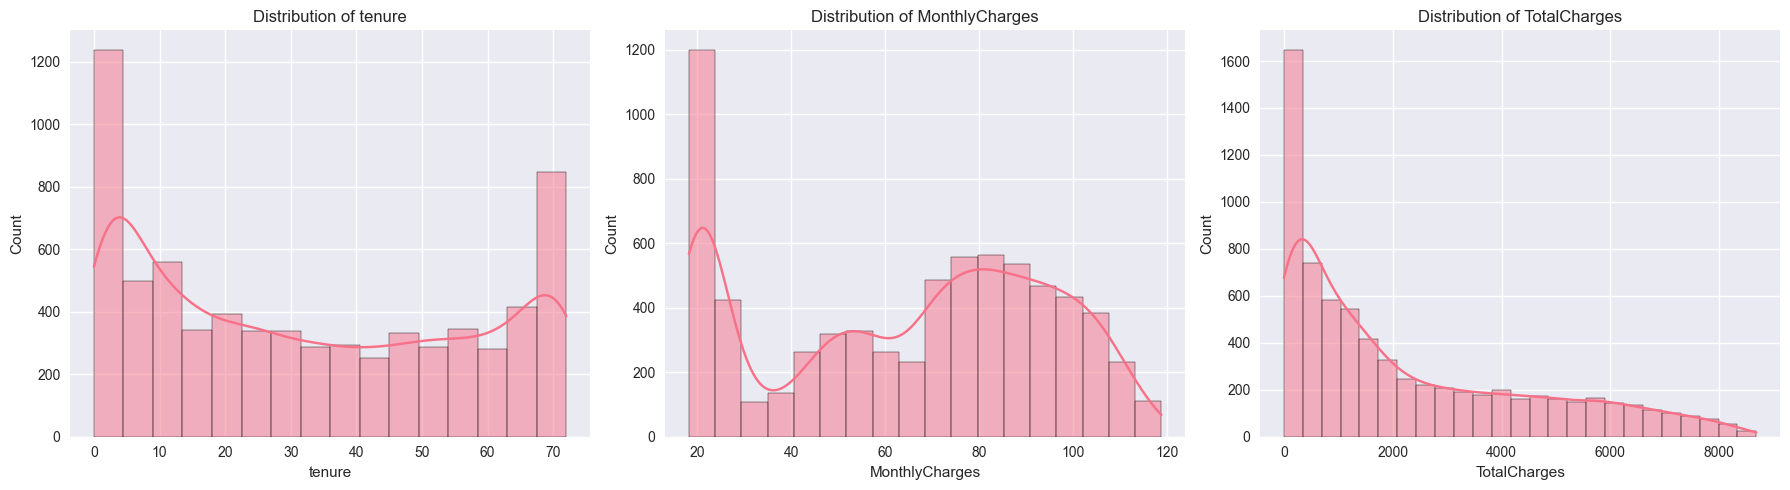

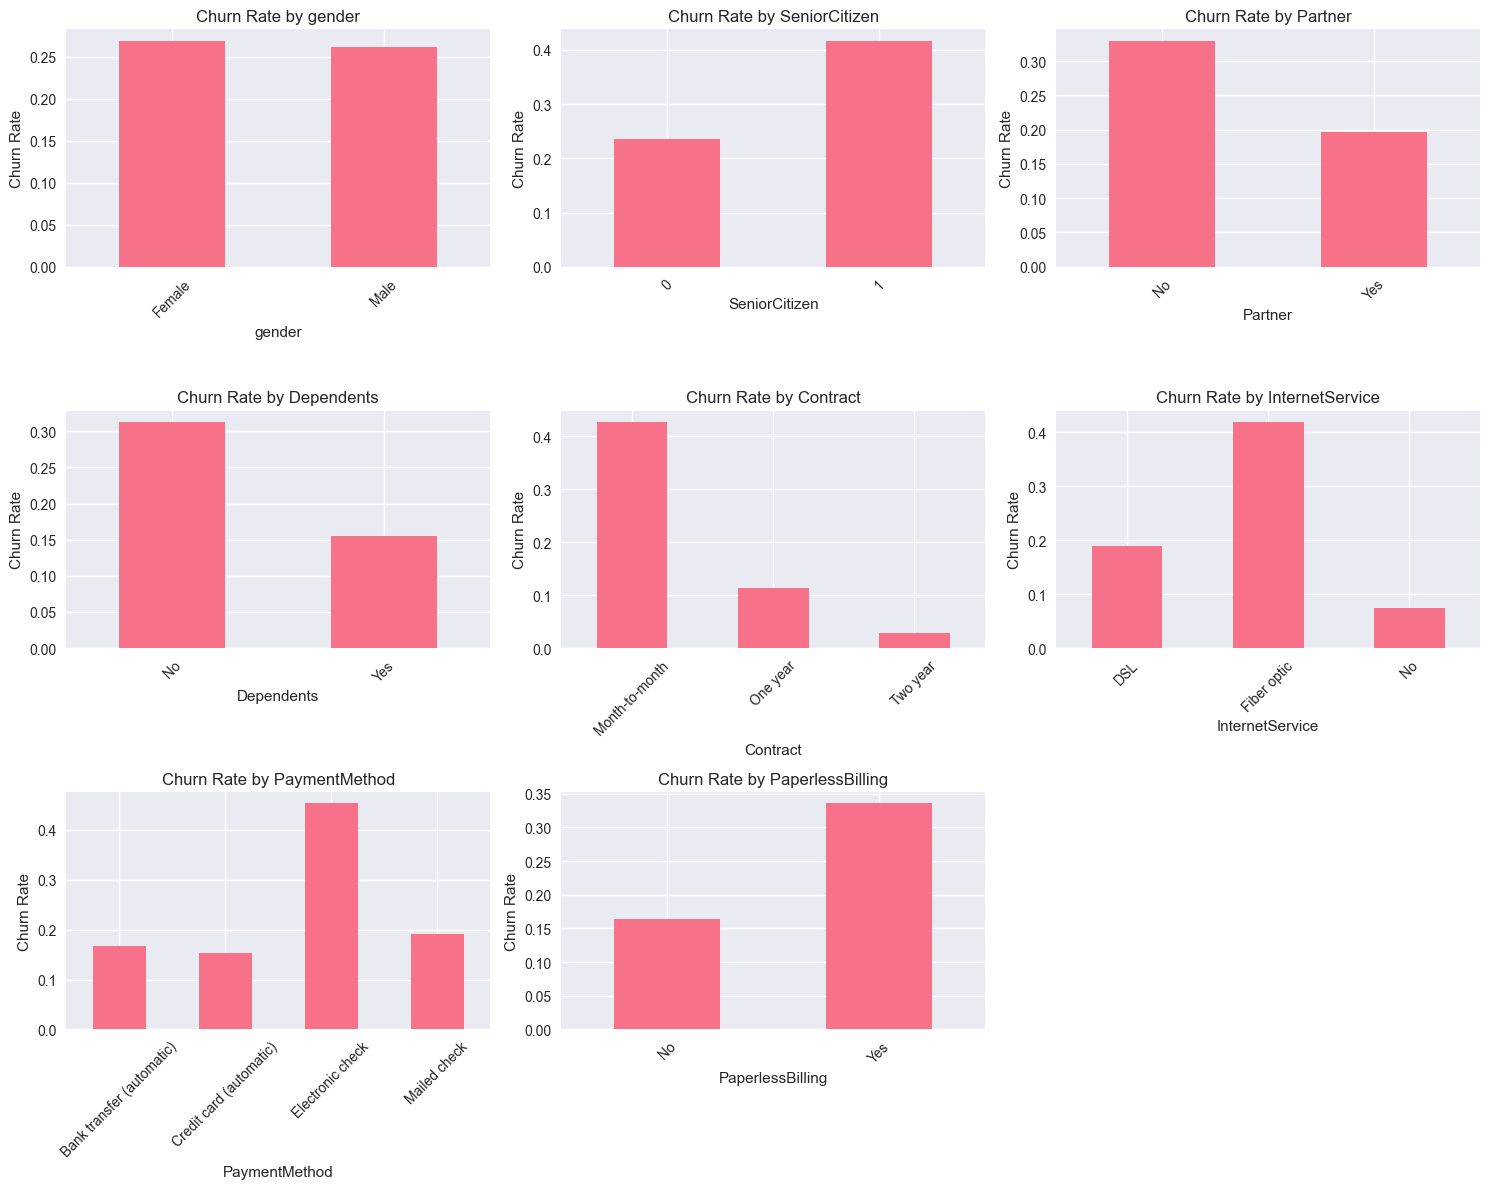

In [5]:
# Numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
os.makedirs('../src/figures', exist_ok=True)
plt.savefig('../src/figures/num_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Categorical features - churn rate by category (key insight plots)
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 
            'InternetService', 'PaymentMethod', 'PaperlessBilling']

plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()['Yes']
    churn_rate.plot(kind='bar')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../src/figures/churn_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Bivariate Analysis & Key Insights

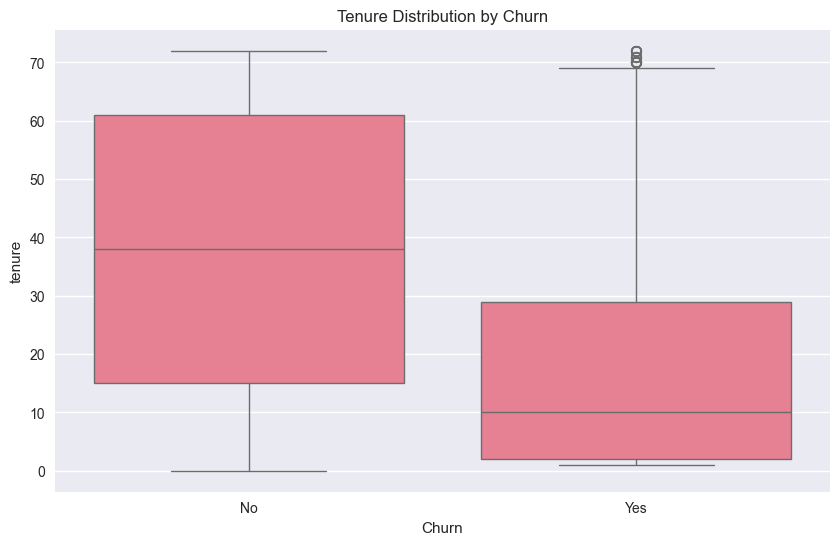

Churn rate by Contract type:
 Contract
Month-to-month   0.43
One year         0.11
Two year         0.03
Name: Yes, dtype: float64


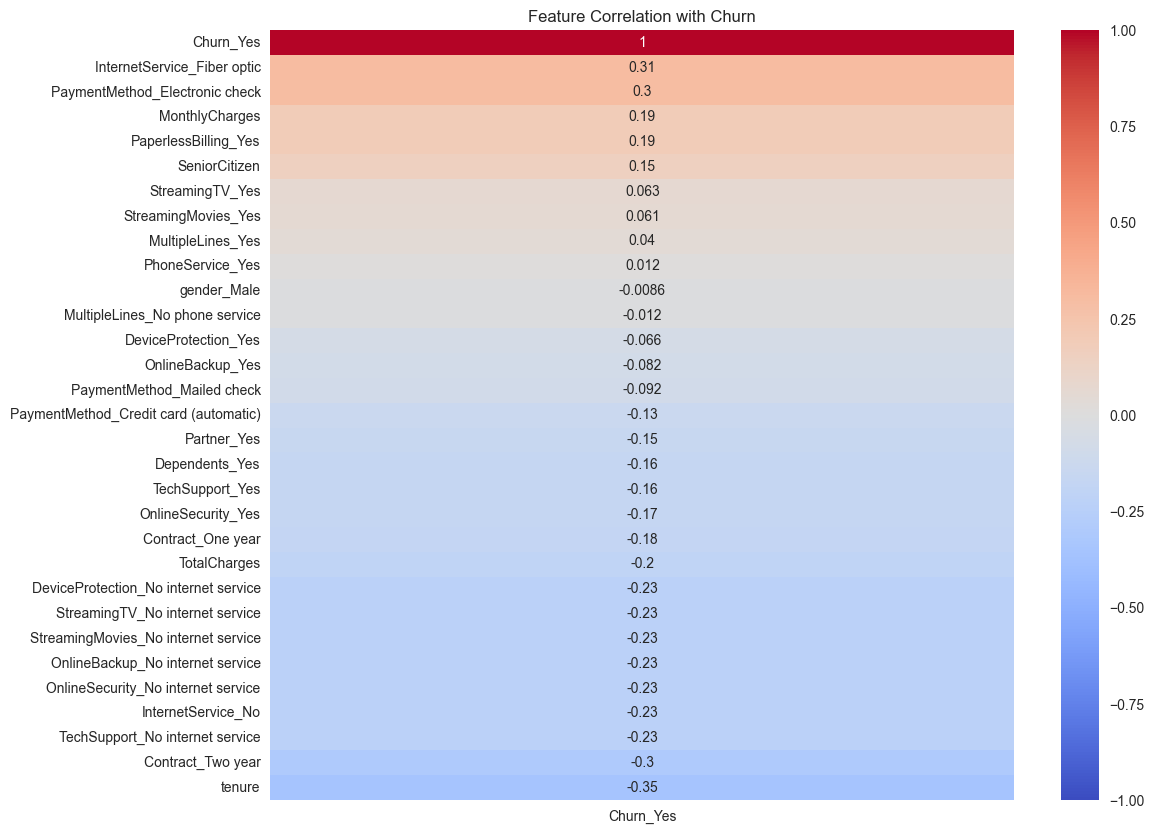

In [6]:
# Tenure vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution by Churn')
plt.savefig('../src/figures/tenure_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# Contract type is usually the strongest predictor
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
print("Churn rate by Contract type:\n", contract_churn['Yes'])

# Correlation (after quick encoding for visualization)
df_encoded = pd.get_dummies(df, drop_first=True)
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr()[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Churn')
plt.savefig('../src/figures/correlation_with_churn.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Feature Engineering

In [7]:
# Create new informative features
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

df['Has_Streaming'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)
df['Has_OnlineSecurity'] = (df['OnlineSecurity'] == 'Yes').astype(int)
df['Has_TechSupport'] = (df['TechSupport'] == 'Yes').astype(int)
df['FiberOptic'] = (df['InternetService'] == 'Fiber optic').astype(int)
df['NoInternet'] = (df['InternetService'] == 'No').astype(int)

# Tenure groups
df['TenureGroup'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72, 100], 
                           labels=['0-12', '13-24', '25-48', '49-72', '72+'])

print("Feature engineering completed. New columns added.")
df.head()

Feature engineering completed. New columns added.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge,Has_Streaming,Has_OnlineSecurity,Has_TechSupport,FiberOptic,NoInternet,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,0,0,0,0,0,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,55.57,0,1,0,0,0,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.08,0,1,0,0,0,0-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.91,0,1,1,0,0,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.83,0,0,0,1,0,0-12


## 8. Final Preprocessing Pipeline & Train/Test Split

In [8]:
# Define feature types
target = 'Churn'
X = df.drop(target, axis=1)
y = df[target].map({'Yes': 1, 'No': 0})

# Identify column types
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge']

binary_features = ['SeniorCitizen', 'Has_Streaming', 'Has_OnlineSecurity', 'Has_TechSupport',
                   'FiberOptic', 'NoInternet']

cat_features = [col for col in X.columns
                if col not in num_features and col not in binary_features]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('bin', 'passthrough', binary_features),   # already 0/1
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='ignore'), cat_features)
])



# Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.4f}")
print(f"Churn rate in test: {y_test.mean():.4f}")

# Fit preprocessor on train only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing pipeline fitted successfully.")

Train shape: (5634, 26), Test shape: (1409, 26)
Churn rate in train: 0.2654
Churn rate in test: 0.2654
Preprocessing pipeline fitted successfully.


## 9. Save All Artifacts

In [9]:
# Create directories if they don't exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../src/models', exist_ok=True)
os.makedirs('../src/figures', exist_ok=True)

# Save processed data
pd.DataFrame(X_train_processed).to_csv('../data/processed/X_train_processed.csv', index=False)
pd.DataFrame(X_test_processed).to_csv('../data/processed/X_test_processed.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# Save fitted preprocessor
joblib.dump(preprocessor, '../src/models/preprocessor.joblib')

print("All artifacts saved successfully!")

All artifacts saved successfully!


## 10. Summary of Key Insights & Recommendations for Modeling

**Main Findings:**
1. **Strongest churn drivers**: Month-to-month contract, Fiber optic internet, low tenure, high monthly charges, no tech support/online security.
2. **Class imbalance**: ~26.5% churn (need to handle with class weights or SMOTE in Phase 2).
3. **Data quality**: Only issue was `TotalCharges` (11 blank values for tenure=0 customers) → imputed safely.
4. **Engineered features** should improve model performance significantly.

**Next Steps (Phase 2):**
- Train multiple classification models (Logistic Regression, Random Forest, XGBoost, LightGBM)
- Handle imbalance
- Hyperparameter tuning + cross-validation
- Feature importance / SHAP analysis

**Phase 1 Complete** ✅